# Flowers Recognition — CNN & Transfer Learning

Dataset: `alxmamaev/flowers-recognition`. This notebook trains and compares five image classifiers: CNN built from scratch and four transfer-learning models (VGG19, EfficientNetB0, MobileNetV2, ResNet50).

## 1. Imports & Configuration

In [1]:
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG19, EfficientNetB0, MobileNetV2, ResNet50

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------

DATA_DIR = pathlib.Path(
    "/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers"
)

SEED = 42

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR)

Dataset exists: True
Dataset path: /kaggle/input/datasets/alxmamaev/flowers-recognition/flowers


## 2. Dataset Loading & Exploration

In [3]:
class_names = sorted([
    item.name
    for item in DATA_DIR.iterdir()
    if item.is_dir()
])

NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [4]:
class_counts = {}

for class_name in class_names:
    class_dir = DATA_DIR / class_name

    image_files = [
        file for file in class_dir.iterdir()
        if file.is_file()
    ]

    class_counts[class_name] = len(image_files)

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

class_counts_df

,Class,Number of Images
0,daisy,764
1,dandelion,1052
2,rose,784
3,sunflower,733
4,tulip,984


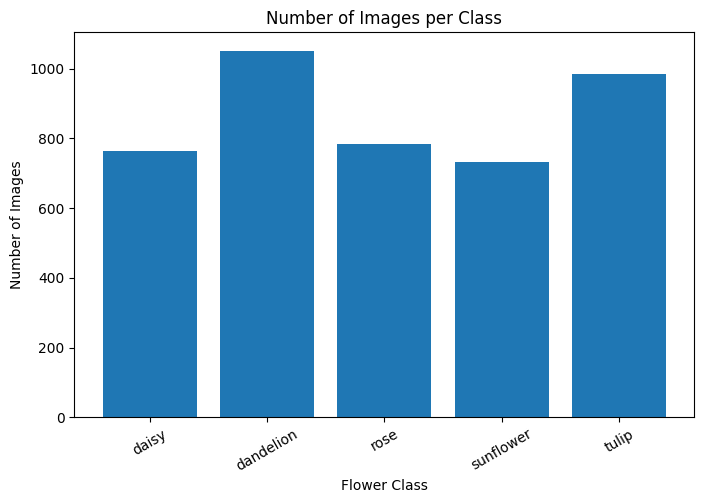

In [5]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_counts_df["Class"],
    class_counts_df["Number of Images"]
)

plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")

plt.xticks(rotation=30)

plt.show()

### Sample Images

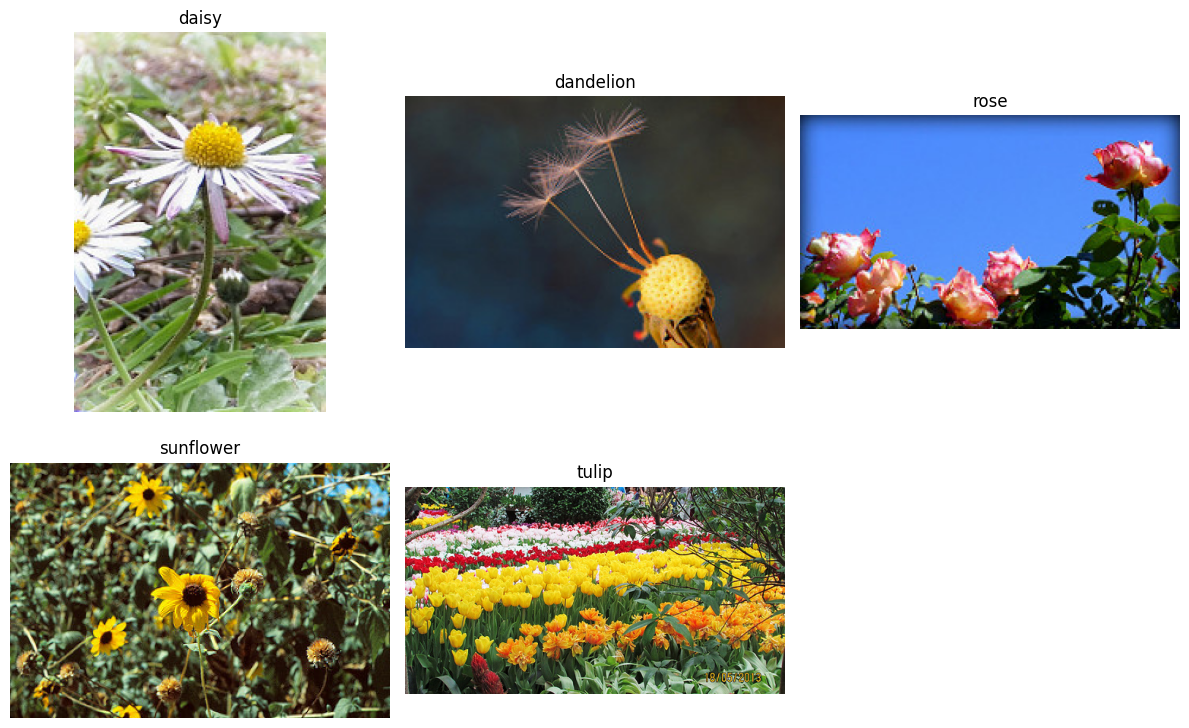

In [6]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):

    class_dir = DATA_DIR / class_name

    image_files = [
        file for file in class_dir.iterdir()
        if file.is_file()
    ]

    image_path = image_files[0]
    image = plt.imread(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Image Dimensions

In [7]:
image_sizes = []

for class_name in class_names:

    class_dir = DATA_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.is_file():

            try:
                with Image.open(image_path) as img:
                    image_sizes.append(img.size)
            except:
                pass

sizes_df = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

sizes_df.describe()

,Width,Height
count,4317.000000,4317.000000
mean,338.379893,253.073662
std,119.067232,61.558205
min,134.000000,80.000000
25%,240.000000,214.000000
50%,320.000000,240.000000
75%,500.000000,329.000000
max,1024.000000,442.000000


In [13]:
sizes_df.value_counts().head(10)

Width  Height
320    240       604
500    333       599
240    159       378
320    213       322
240    240       219
180    240       154
159    240       141
500    375       124
       332       118
240    180        69
Name: count, dtype: int64

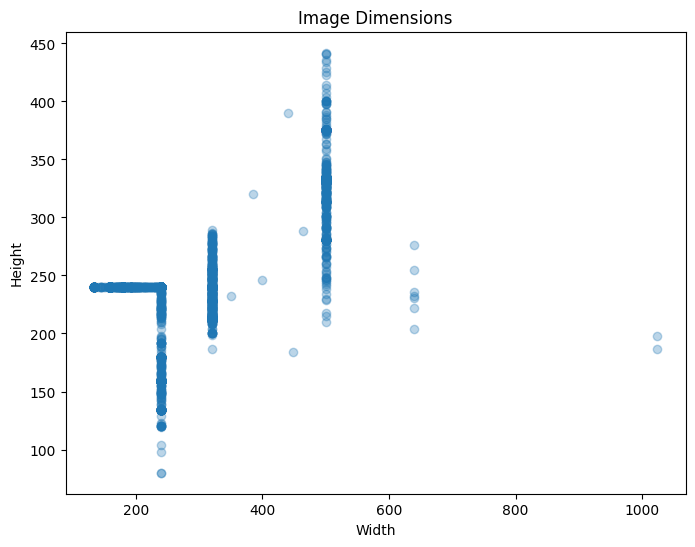

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    sizes_df["Width"],
    sizes_df["Height"],
    alpha=0.3
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Dimensions")

plt.show()

### Loading train/validation datasets

A shared helper is used so that every model loads data the same way, with the
same `validation_split` and the same `SEED` (only `IMG_HEIGHT`/`IMG_WIDTH`/
`BATCH_SIZE`).

In [15]:
def load_datasets(img_height, img_width, batch_size, seed=SEED, use_cache=False):

    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="training",
        seed=seed,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode="int"
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="validation",
        seed=seed,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode="int"
    )

    AUTOTUNE = tf.data.AUTOTUNE

    if use_cache:
        train_ds = train_ds.cache().shuffle(1000, seed=seed).prefetch(AUTOTUNE)
        val_ds = val_ds.cache().prefetch(AUTOTUNE)
    else:
        train_ds = train_ds.shuffle(1000, seed=seed).prefetch(AUTOTUNE)
        val_ds = val_ds.prefetch(AUTOTUNE)

    return train_ds, val_ds

In [17]:
_preview_train_ds, _ = load_datasets(IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, use_cache=False)

print("Classes:", class_names)

for images, labels in _preview_train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

del _preview_train_ds

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


## Data Augmentation

In [18]:
data_augmentation_common = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05)
], name="data_augmentation_common")

## 4. Evaluation & Plotting Functions

In [20]:
def plot_training_history(history, model_name):

    plt.figure(figsize=(10, 6))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [21]:
def evaluate_model(model, val_ds, class_names, model_name):
    
    val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)
    print(f"\nValidation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

    y_true = []
    y_pred = []

    for images, labels in val_ds:
        predictions = model.predict(images, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_classes)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    accuracy = accuracy_score(y_true, y_pred)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print("\n==============================")
    print("FINAL METRICS")
    print("==============================")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "Best Val Accuracy": val_accuracy,
    }

In [22]:
def show_incorrect_predictions(model, val_ds, class_names, model_name, max_images=12):

    incorrect_images = []
    incorrect_true = []
    incorrect_pred = []

    for images, labels in val_ds:
        predictions = model.predict(images, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)

        for i in range(len(images)):
            if predicted_classes[i] != labels[i].numpy():
                incorrect_images.append(images[i].numpy().astype("uint8"))
                incorrect_true.append(class_names[labels[i].numpy()])
                incorrect_pred.append(class_names[predicted_classes[i]])

    num_errors = min(max_images, len(incorrect_images))

    if num_errors == 0:
        print("No incorrect predictions found.")
        return

    plt.figure(figsize=(12, 8))

    for i in range(num_errors):
        plt.subplot(3, 4, i + 1)
        plt.imshow(incorrect_images[i])
        plt.title(f"True: {incorrect_true[i]}\nPred: {incorrect_pred[i]}")
        plt.axis("off")

    plt.suptitle(f"{model_name} - Misclassified Examples")
    plt.tight_layout()
    plt.show()

In [23]:
# Collects the dict returned by evaluate_model() for every trained model,
all_results = []

# Model Experiments

## 6. CNN From Scratch

In [24]:
# ------------------------------------------------------------
# Configuration specific to this model (smaller input size than the rest)
# ------------------------------------------------------------

CNN1_IMG_HEIGHT = 180
CNN1_IMG_WIDTH = 180
CNN1_BATCH_SIZE = 32

train_ds_cnn1, val_ds_cnn1 = load_datasets(
    CNN1_IMG_HEIGHT, CNN1_IMG_WIDTH, CNN1_BATCH_SIZE, use_cache=False
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [25]:
data_augmentation_cnn1 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation_cnn1")

In [26]:
cnn1_model = keras.Sequential([

    layers.Input(shape=(CNN1_IMG_HEIGHT, CNN1_IMG_WIDTH, 3)),

    data_augmentation_cnn1,

    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # Classification head
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

cnn1_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_cnn1          │ (None, 180, 180, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,877 (30.61 MB)

 Trainable params: 8,023,877 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
cnn1_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

cnn1_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

cnn1_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [28]:
cnn1_history = cnn1_model.fit(
    train_ds_cnn1,
    validation_data=val_ds_cnn1,
    epochs=30,
    callbacks=[cnn1_early_stopping, cnn1_reduce_lr]
)

Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.4117 - loss: 1.3686 - val_accuracy: 0.5191 - val_loss: 1.0899 - learning_rate: 0.0010
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.5426 - loss: 1.1191 - val_accuracy: 0.6025 - val_loss: 0.9776 - learning_rate: 0.0010
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.5886 - loss: 1.0475 - val_accuracy: 0.6396 - val_loss: 0.9085 - learning_rate: 0.0010
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.6230 - loss: 0.9929 - val_accuracy: 0.6373 - val_loss: 0.9186 - learning_rate: 0.0010
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.6503 - loss: 0.9187 - val_accuracy: 0.6524 - val_loss: 0.8558 - learning_rate: 0.0010
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.6673 - loss: 0.8852 - val_accuracy: 0.6964 - val_loss: 0.7742 - learning_rate: 0.0010
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.6824 - loss: 0

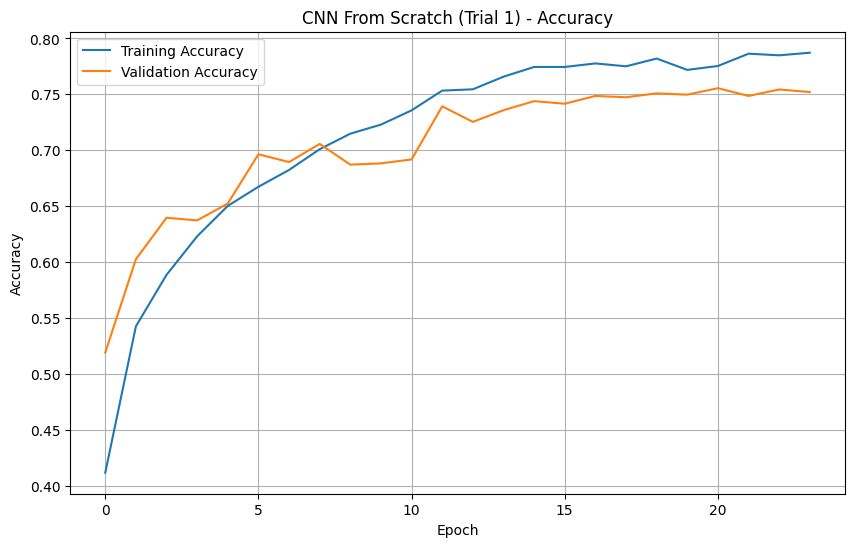

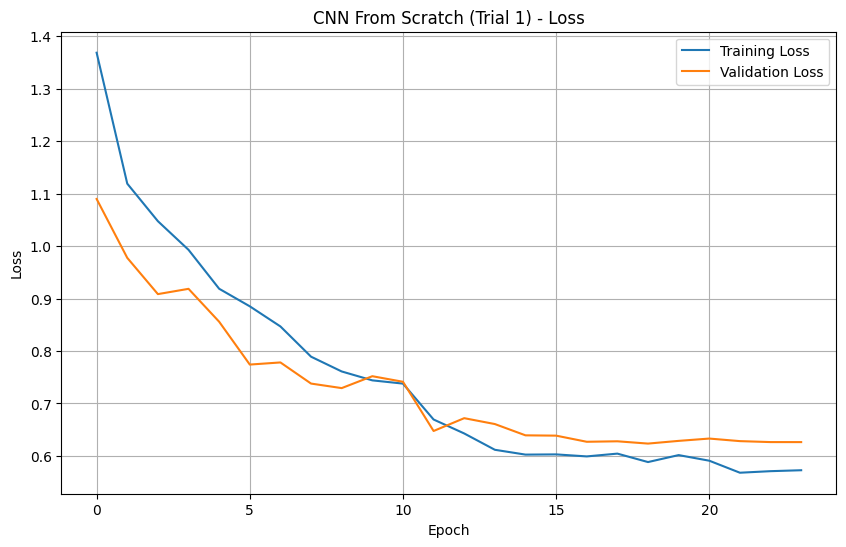

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7509 - loss: 0.6236

Validation Loss: 0.6236
Validation Accuracy: 0.7509

Classification Report:

              precision    recall  f1-score   support

       daisy     0.7868    0.7431    0.7643       144
   dandelion     0.8039    0.7961    0.8000       206
        rose     0.5918    0.6350    0.6127       137
   sunflower     0.7795    0.8837    0.8283       172
       tulip     0.7624    0.6765    0.7169       204

    accuracy                         0.7509       863
   macro avg     0.7449    0.7469    0.7444       863
weighted avg     0.7527    0.7509    0.7503       863


FINAL METRICS
Accuracy:    0.7509
Weighted F1: 0.7503
Macro F1:    0.7444


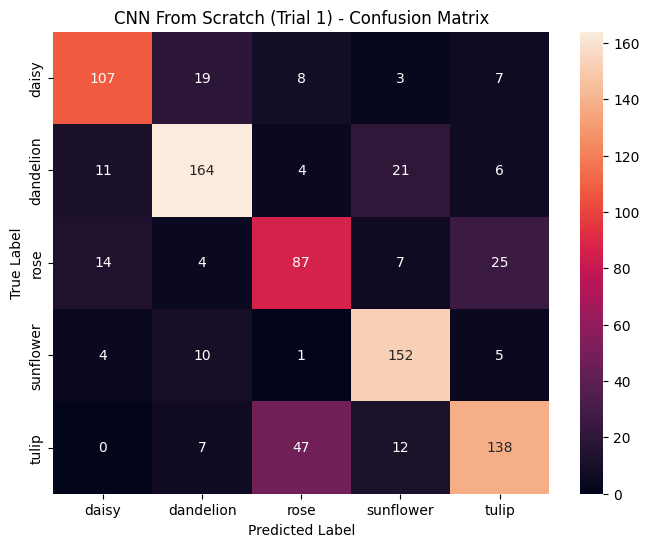

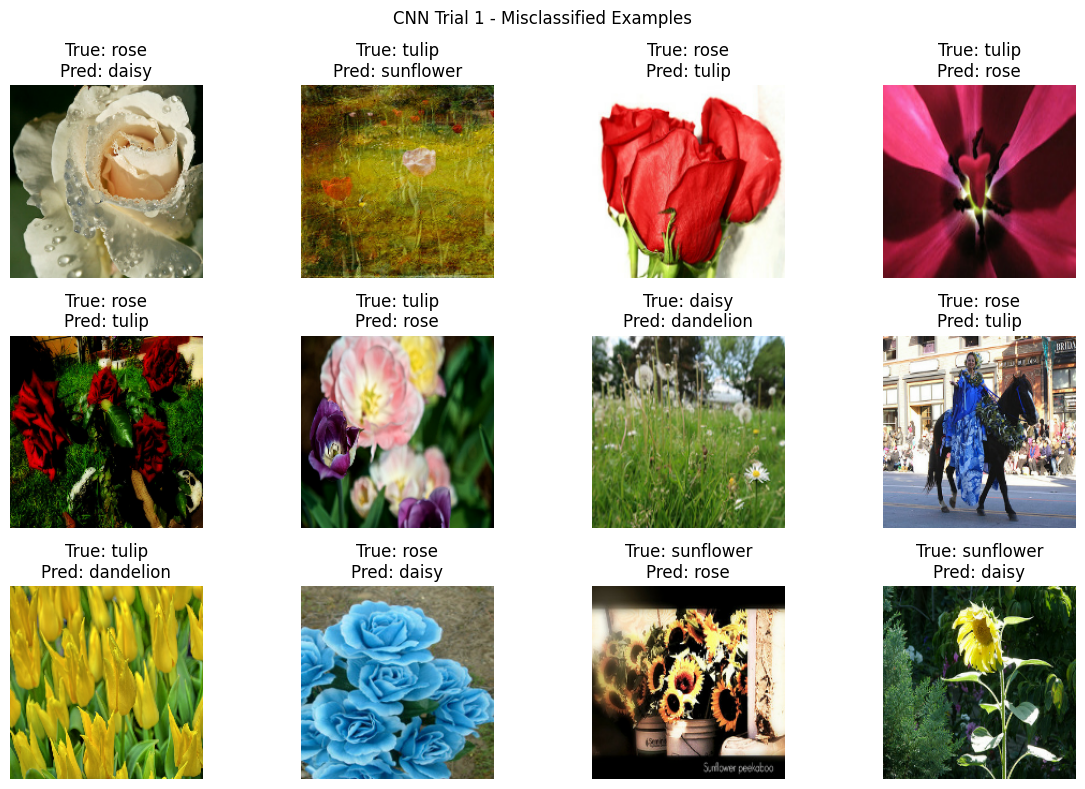

In [29]:
plot_training_history(cnn1_history, "CNN From Scratch (Trial 1)")

cnn1_results = evaluate_model(
    cnn1_model, val_ds_cnn1, class_names, "CNN From Scratch (Trial 1)"
)
all_results.append(cnn1_results)

show_incorrect_predictions(cnn1_model, val_ds_cnn1, class_names, "CNN Trial 1")

In [30]:
cnn1_model.save("/kaggle/working/flowers_cnn.keras")

## 7. VGG19

In [38]:
VGG19_BATCH_SIZE = 64

train_ds_vgg19, val_ds_vgg19 = load_datasets(
    IMG_HEIGHT, IMG_WIDTH, VGG19_BATCH_SIZE, use_cache=False
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [40]:
with tf.device("/GPU:0"):
    vgg19_base_model = VGG19(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights="imagenet"
    )

# Freeze the first 19 layers, keep the rest trainable
for layer in vgg19_base_model.layers[:19]:
    layer.trainable = False

for layer in vgg19_base_model.layers[19:]:
    layer.trainable = True

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
vgg19_model = Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    data_augmentation_common,

    layers.Lambda(keras.applications.vgg19.preprocess_input),

    vgg19_base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

vgg19_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg19_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_common        │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,693 (76.64 MB)

 Trainable params: 4,785,925 (18.26 MB)

 Non-trainable params: 15,304,768 (58.38 MB)

In [42]:
vgg19_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=1e-6
)

vgg19_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [43]:
vgg19_history = vgg19_model.fit(
    train_ds_vgg19,
    validation_data=val_ds_vgg19,
    epochs=12,
    callbacks=[vgg19_reduce_lr, vgg19_early_stopping],
    verbose=1
)

Epoch 1/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 636ms/step - accuracy: 0.5851 - loss: 1.3005 - val_accuracy: 0.8158 - val_loss: 0.4992 - learning_rate: 1.0000e-04
Epoch 2/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 405ms/step - accuracy: 0.8098 - loss: 0.5088 - val_accuracy: 0.8737 - val_loss: 0.3839 - learning_rate: 1.0000e-04
Epoch 3/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 408ms/step - accuracy: 0.8616 - loss: 0.3975 - val_accuracy: 0.8633 - val_loss: 0.3827 - learning_rate: 1.0000e-04
Epoch 4/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 415ms/step - accuracy: 0.8822 - loss: 0.3313 - val_accuracy: 0.9003 - val_loss: 0.3374 - learning_rate: 1.0000e-04
Epoch 5/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 411ms/step - accuracy: 0.9065 - loss: 0.2695 - val_accuracy: 0.8992 - val_loss: 0.3411 - learning_rate: 1.0000e-04
Epoch 6/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9254 - loss: 0.2220
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 411ms/step - accuracy

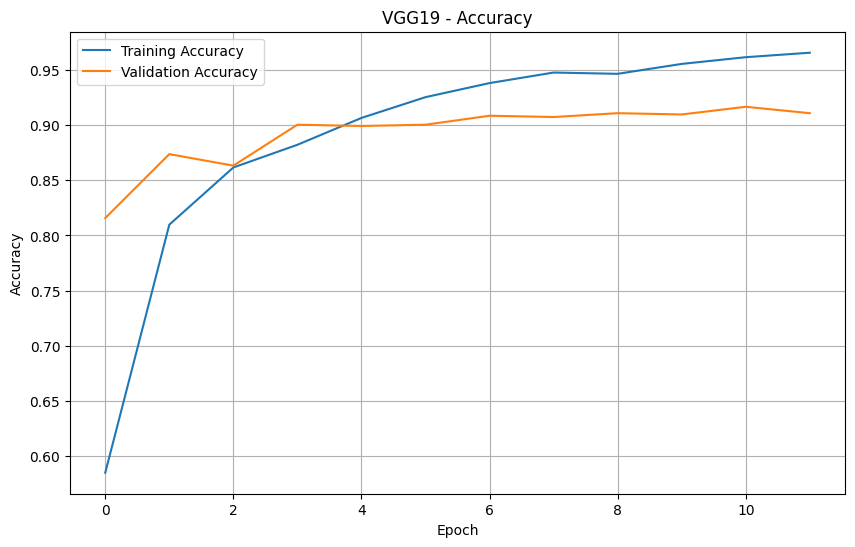

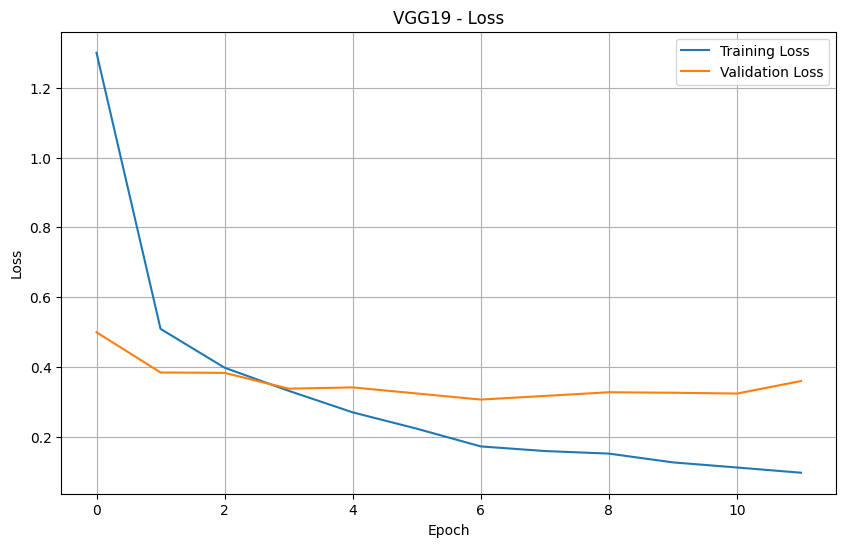

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 295ms/step - accuracy: 0.9166 - loss: 0.3234

Validation Loss: 0.3234
Validation Accuracy: 0.9166

Classification Report:

              precision    recall  f1-score   support

       daisy     0.9412    0.8889    0.9143       144
   dandelion     0.9227    0.9272    0.9249       206
        rose     0.8815    0.8686    0.8750       137
   sunflower     0.9535    0.9535    0.9535       172
       tulip     0.8873    0.9265    0.9065       204

    accuracy                         0.9166       863
   macro avg     0.9172    0.9129    0.9148       863
weighted avg     0.9170    0.9166    0.9166       863


FINAL METRICS
Accuracy:    0.9166
Weighted F1: 0.9166
Macro F1:    0.9148


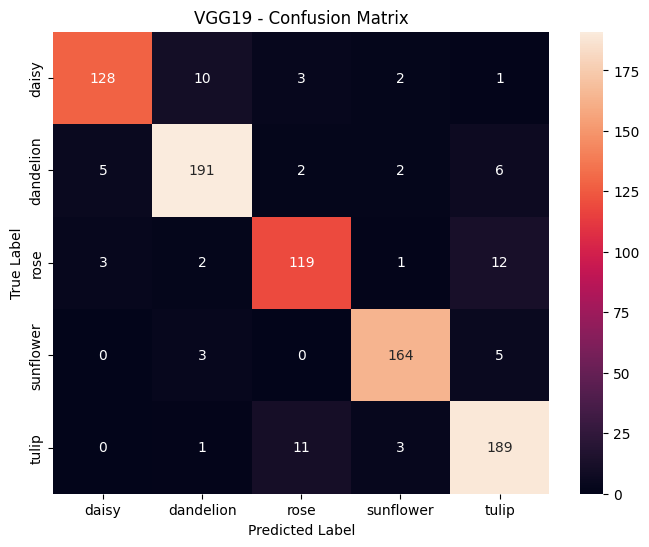

In [44]:
plot_training_history(vgg19_history, "VGG19")

vgg19_results = evaluate_model(vgg19_model, val_ds_vgg19, class_names, "VGG19")
all_results.append(vgg19_results)

In [45]:
vgg19_model.save("/kaggle/working/flowers_vgg19.keras")

## 8. EfficientNetB0

In [46]:
train_ds_effnet, val_ds_effnet = load_datasets(
    IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, use_cache=False
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [47]:
effnet_base_model = EfficientNetB0(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze backbone
effnet_base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
effnet_model = Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    data_augmentation_common,

    effnet_base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

effnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

effnet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_common        │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [49]:
effnet_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

effnet_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [50]:
effnet_history = effnet_model.fit(
    train_ds_effnet,
    validation_data=val_ds_effnet,
    epochs=15,
    callbacks=[effnet_reduce_lr, effnet_early_stopping]
)

Epoch 1/15


E0000 00:00:1788344360.730463      59 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 125ms/step - accuracy: 0.6821 - loss: 0.8518 - val_accuracy: 0.8552 - val_loss: 0.4659 - learning_rate: 0.0010
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.8286 - loss: 0.4845 - val_accuracy: 0.8899 - val_loss: 0.3486 - learning_rate: 0.0010
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - accuracy: 0.8567 - loss: 0.4126 - val_accuracy: 0.8980 - val_loss: 0.3057 - learning_rate: 0.0010
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.8697 - loss: 0.3764 - val_accuracy: 0.8992 - val_loss: 0.2798 - learning_rate: 0.0010
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.8894 - loss: 0.3369 - val_accuracy: 0.9061 - val_loss: 0.2704 - learning_rate: 0.0010
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.8900 - loss: 0.3191 - val_accuracy: 0.9143 - val_loss: 0.2593 - learning_rate: 0.0010
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.8885 - loss: 0.304

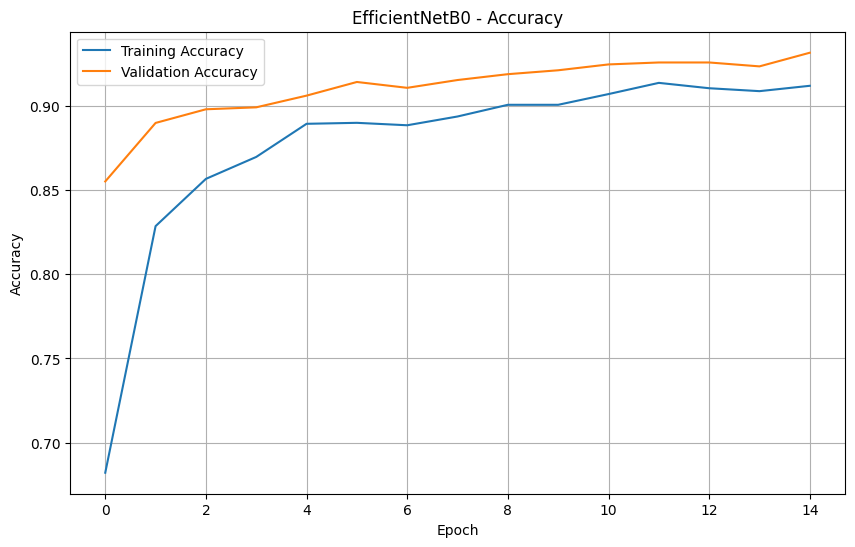

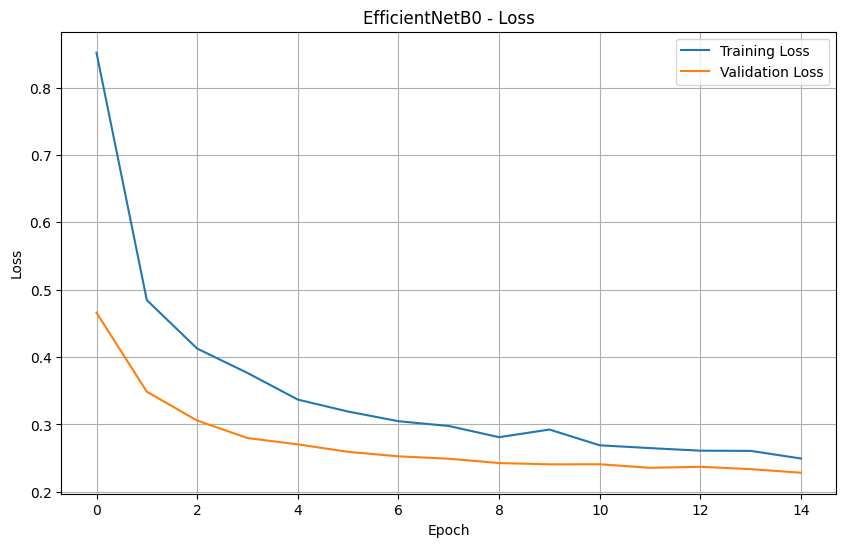

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9316 - loss: 0.2283

Validation Loss: 0.2283
Validation Accuracy: 0.9316

Classification Report:

              precision    recall  f1-score   support

       daisy     0.9552    0.8889    0.9209       144
   dandelion     0.9652    0.9417    0.9533       206
        rose     0.9118    0.9051    0.9084       137
   sunflower     0.9167    0.9593    0.9375       172
       tulip     0.9104    0.9461    0.9279       204

    accuracy                         0.9316       863
   macro avg     0.9318    0.9282    0.9296       863
weighted avg     0.9324    0.9316    0.9316       863


FINAL METRICS
Accuracy:    0.9316
Weighted F1: 0.9316
Macro F1:    0.9296


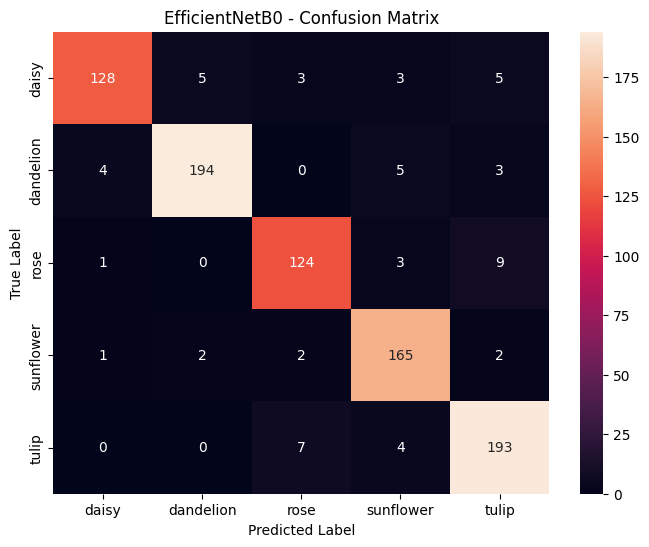

In [51]:
plot_training_history(effnet_history, "EfficientNetB0")

effnet_results = evaluate_model(effnet_model, val_ds_effnet, class_names, "EfficientNetB0")
all_results.append(effnet_results)

In [52]:
effnet_model.save("/kaggle/working/flowers_efficientnetb0.keras")

## 9. MobileNetV2

In [53]:
train_ds_mobilenet, val_ds_mobilenet = load_datasets(
    IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, use_cache=False
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [54]:
mobilenet_base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

mobilenet_base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [55]:
mobilenet_model = Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    data_augmentation_common,

    # MobileNetV2 preprocessing ([-1, 1] scaling)
    layers.Rescaling(1./127.5, offset=-1),

    mobilenet_base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_common        │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [56]:
mobilenet_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

mobilenet_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [57]:
mobilenet_history = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=15,
    callbacks=[mobilenet_reduce_lr, mobilenet_early_stopping]
)

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.6462 - loss: 0.9246 - val_accuracy: 0.7856 - val_loss: 0.5539 - learning_rate: 0.0010
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7918 - loss: 0.5762 - val_accuracy: 0.8505 - val_loss: 0.4430 - learning_rate: 0.0010
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8208 - loss: 0.4943 - val_accuracy: 0.8575 - val_loss: 0.3895 - learning_rate: 0.0010
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8361 - loss: 0.4428 - val_accuracy: 0.8772 - val_loss: 0.3734 - learning_rate: 0.0010
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8480 - loss: 0.4245 - val_accuracy: 0.8760 - val_loss: 0.3611 - learning_rate: 0.0010
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8561 - loss: 0.3925 - val_accuracy: 0.8725 - val_loss: 0.3582 - learning_rate: 0.0010
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8578 - l

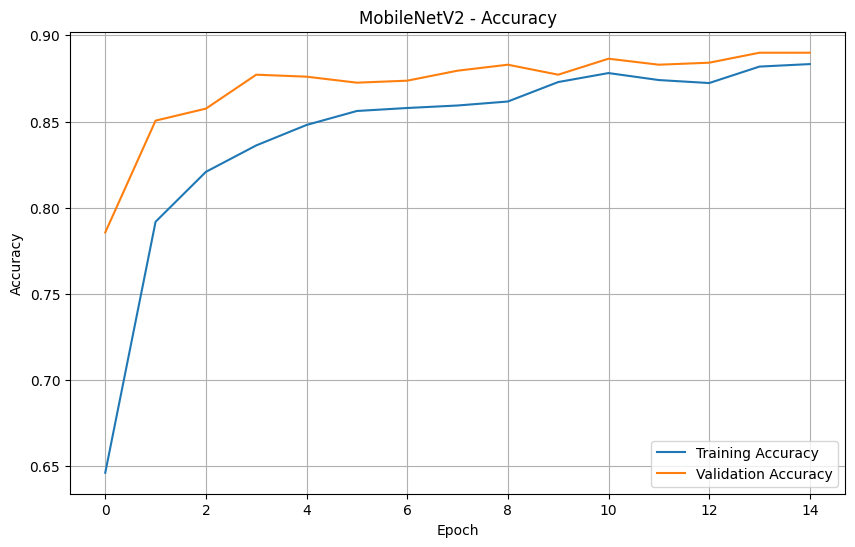

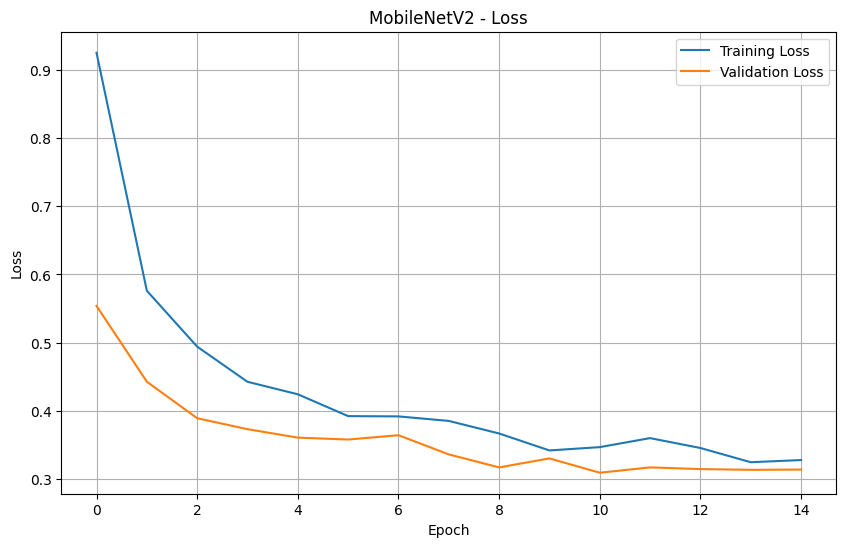

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8864 - loss: 0.3097

Validation Loss: 0.3097
Validation Accuracy: 0.8864

Classification Report:

              precision    recall  f1-score   support

       daisy     0.8811    0.8750    0.8780       144
   dandelion     0.9227    0.8689    0.8950       206
        rose     0.8117    0.9124    0.8591       137
   sunflower     0.8715    0.9070    0.8889       172
       tulip     0.9275    0.8775    0.9018       204

    accuracy                         0.8864       863
   macro avg     0.8829    0.8882    0.8846       863
weighted avg     0.8891    0.8864    0.8869       863


FINAL METRICS
Accuracy:    0.8864
Weighted F1: 0.8869
Macro F1:    0.8846


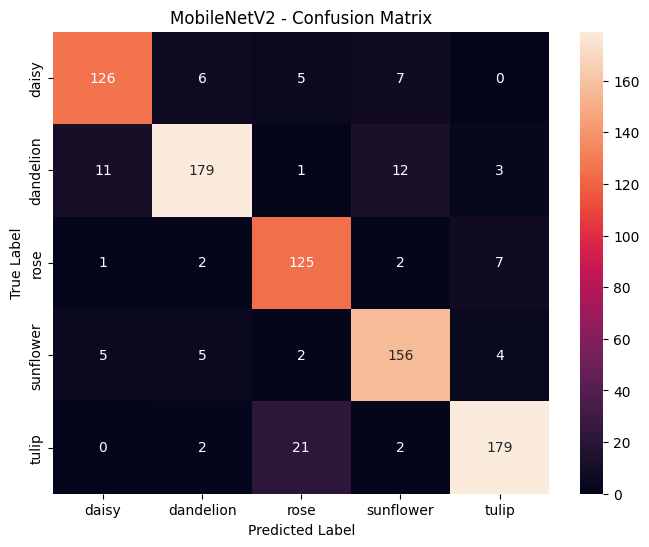

In [58]:
plot_training_history(mobilenet_history, "MobileNetV2")

mobilenet_results = evaluate_model(mobilenet_model, val_ds_mobilenet, class_names, "MobileNetV2")
all_results.append(mobilenet_results)

In [59]:
mobilenet_model.save("/kaggle/working/flowers_mobilenetv2.keras")

## 10. ResNet50

In [60]:
train_ds_resnet, val_ds_resnet = load_datasets(
    IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, use_cache=False
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [61]:
resnet_base_model = ResNet50(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

resnet_base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [62]:
resnet_model = Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    data_augmentation_common,

    layers.Lambda(keras.applications.resnet50.preprocess_input),

    resnet_base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_common        │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [63]:
resnet_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

resnet_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [64]:
resnet_history = resnet_model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=15,
    callbacks=[resnet_reduce_lr, resnet_early_stopping]
)

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 201ms/step - accuracy: 0.7137 - loss: 0.8054 - val_accuracy: 0.8633 - val_loss: 0.4059 - learning_rate: 0.0010
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.8402 - loss: 0.4585 - val_accuracy: 0.8922 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.8576 - loss: 0.3856 - val_accuracy: 0.8934 - val_loss: 0.3080 - learning_rate: 0.0010
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.8717 - loss: 0.3530 - val_accuracy: 0.8957 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.8897 - loss: 0.3208 - val_accuracy: 0.9073 - val_loss: 0.2817 - learning_rate: 0.0010
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step - accuracy: 0.8937 - loss: 0.3051 - val_accuracy: 0.9073 - val_loss: 0.2807 - learning_rate: 0.0010
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.8

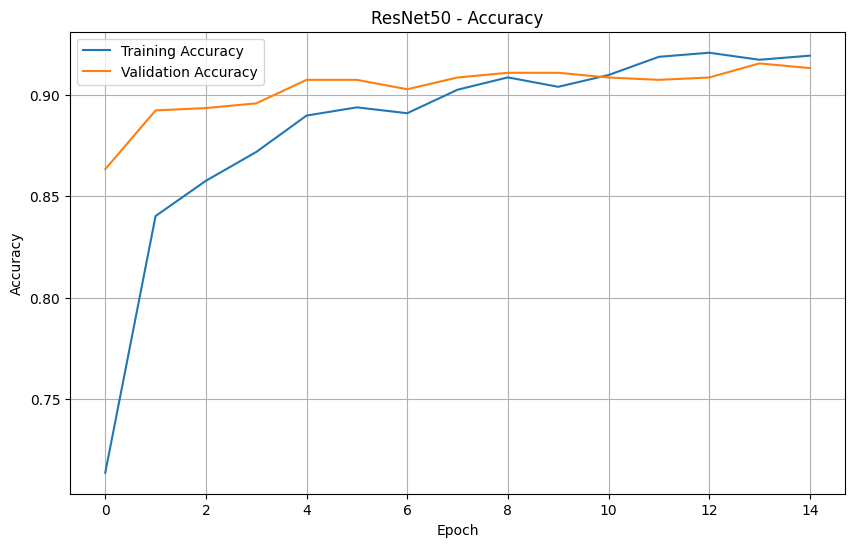

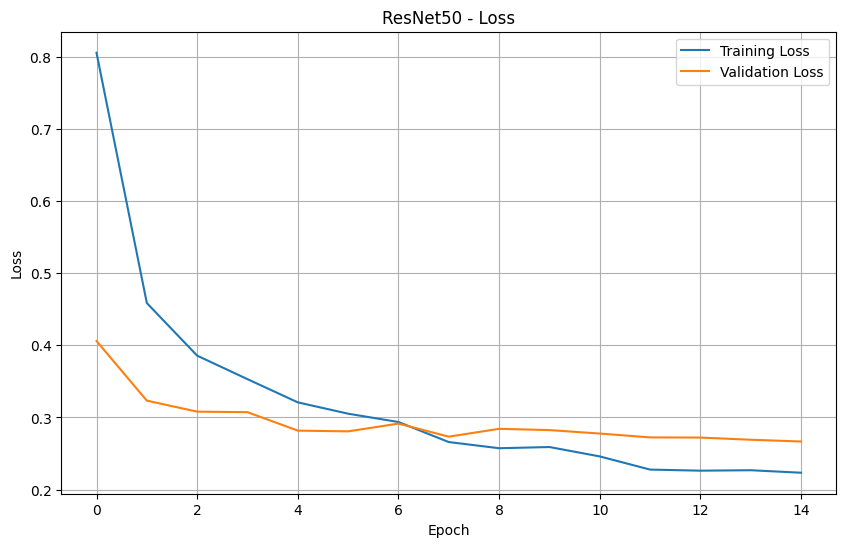

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.9131 - loss: 0.2666

Validation Loss: 0.2666
Validation Accuracy: 0.9131

Classification Report:

              precision    recall  f1-score   support

       daisy     0.8776    0.8958    0.8866       144
   dandelion     0.9548    0.9223    0.9383       206
        rose     0.8551    0.8613    0.8582       137
   sunflower     0.9538    0.9593    0.9565       172
       tulip     0.9029    0.9118    0.9073       204

    accuracy                         0.9131       863
   macro avg     0.9088    0.9101    0.9094       863
weighted avg     0.9136    0.9131    0.9133       863


FINAL METRICS
Accuracy:    0.9131
Weighted F1: 0.9133
Macro F1:    0.9094


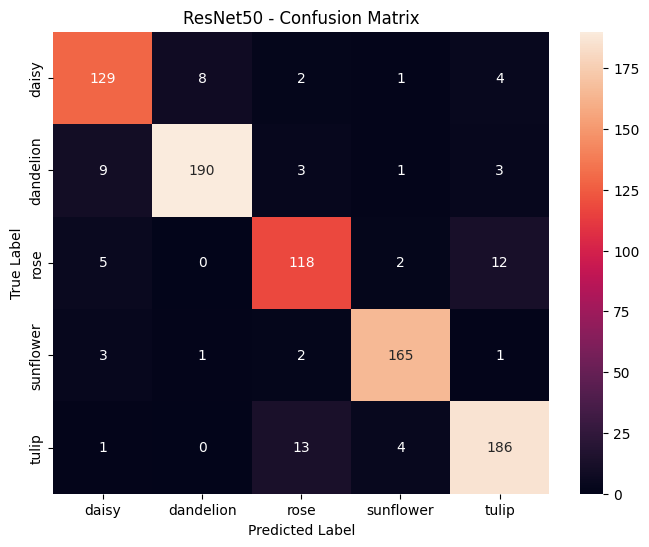

In [65]:
plot_training_history(resnet_history, "ResNet50")

resnet_results = evaluate_model(resnet_model, val_ds_resnet, class_names, "ResNet50")
all_results.append(resnet_results)

In [66]:
resnet_model.save("/kaggle/working/flowers_resnet50.keras")

## 11. Model Comparison

In [75]:
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values(by="Weighted F1", ascending=False).reset_index(drop=True)

comparison_df

,Model,Accuracy,Weighted F1,Macro F1,Best Val Accuracy
0,EfficientNetB0,0.931634,0.931611,0.929598,0.931634
1,VGG19,0.916570,0.916559,0.914838,0.916570
2,ResNet50,0.913094,0.913255,0.909378,0.913094
3,MobileNetV2,0.886443,0.886854,0.884561,0.886443
4,CNN From Scratch,0.750869,0.750304,0.744437,0.750869


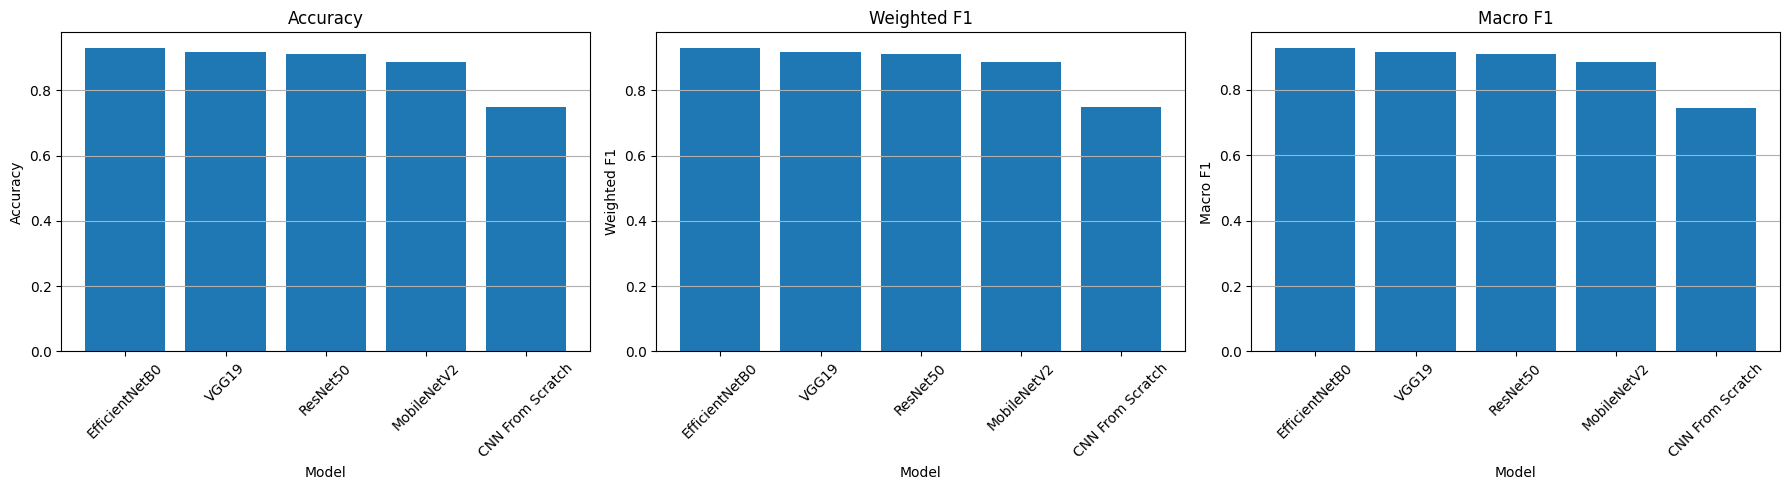

In [76]:
metrics_to_plot = ["Accuracy", "Weighted F1", "Macro F1"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(comparison_df["Model"], comparison_df[metric])
    ax.set_title(metric)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

## 12. Final Best Model

In [77]:
best_row = comparison_df.loc[comparison_df["Weighted F1"].idxmax()]

print("Best model based on Weighted F1-score:")
print(best_row)

Best model based on Weighted F1-score:
Model                EfficientNetB0
Accuracy                   0.931634
Weighted F1                0.931611
Macro F1                   0.929598
Best Val Accuracy          0.931634
Name: 0, dtype: object
